# Titanic Dataset Analysis - IEEE SSCS | AI Sub-Team
## Introduction
This notebook contains a complete data analysis pipeline for the Titanic dataset.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

## Step 1: Load the Data
Our starting point. We get the data into the environment and take the first look at what we are working with.

In [9]:
# Load the dataset
df = pd.read_csv('./titanic.csv')

# Display a random sample of 5 rows
display(df.sample(5))

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
414,415,1,3,"Sundman, Mr. Johan Julian",male,44.0,0,0,STON/O 2. 3101269,7.9250,NaN,S
12,13,0,3,"Saundercock, Mr. William Henry",male,20.0,0,0,A/5. 2151,8.0500,NaN,S
750,751,1,2,"Wells, Miss. Joan",female,4.0,1,1,29103,23.0000,NaN,S
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S
65,66,1,3,"Moubarek, Master. Gerios",male,NaN,1,1,2661,15.2458,NaN,C


## Step 2: Data Cleaning
Real data is messy. Here we will:
1. Drop irrelevant columns (`PassengerId`, `Name`, `Ticket`, `Cabin`).
2. Fix data types for better memory usage.
3. Handle missing values (e.g., filling `Age` with the median).
4. Handle Outliers using the IQR method.
5. Remove duplicates.

In [10]:
# 1. Drop irrelevant columns
columns_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df.drop(columns_to_drop, axis=1, inplace=True)

# 2. Optimize data types (convert categorical columns to 'category')
categorical_cols = ['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked']
df[categorical_cols] = df[categorical_cols].astype('category')

# 3. Handle missing values
# Fill missing 'Age' with the median
median_age = df['Age'].median()
df['Age'].fillna(median_age, inplace=True)

# Fill missing 'Embarked' with the mode
mode_embarked = df['Embarked'].mode()[0]
df['Embarked'].fillna(mode_embarked, inplace=True)

# Check missing values after cleaning
print("Missing values after cleaning:\n", df.isnull().sum())

Missing values after cleaning:
 Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


### Handling Outliers
We will check for continuous numerical columns and cap the outliers using the Interquartile Range (IQR) method.

In [11]:
# Identify continuous numerical columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Cap outliers using Lower and Upper Fences
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    
    # Replace outliers with fence values
    df[col] = np.where(df[col] < lower_fence, lower_fence, df[col])
    df[col] = np.where(df[col] > upper_fence, upper_fence, df[col])

# Remove duplicates
df.drop_duplicates(inplace=True)
print("Data shape after dropping duplicates:", df.shape)

Data shape after dropping duplicates: (762, 8)


## Step 3: Exploratory Data Analysis (EDA)
Digging in. Let's see what patterns, distributions, or relationships we can find using visualizations.

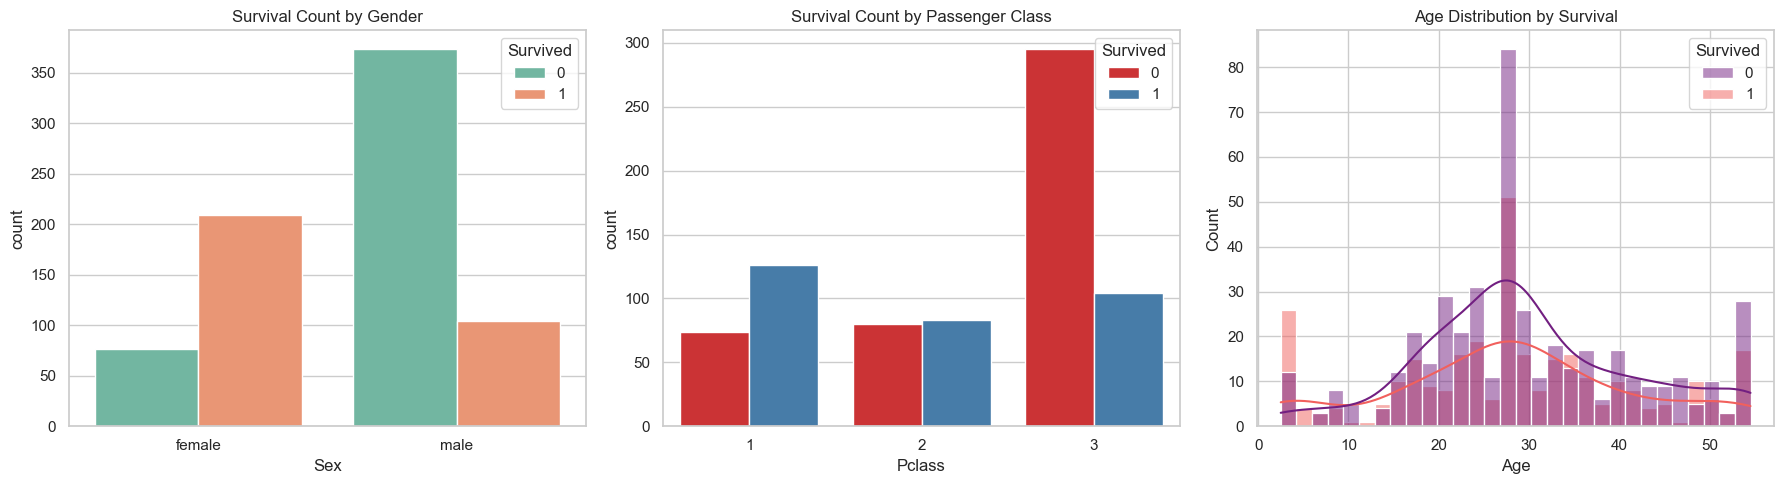

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Survival by Gender
sns.countplot(data=df, x='Sex', hue='Survived', palette='Set2', ax=axes[0])
axes[0].set_title('Survival Count by Gender')

# 2. Survival by Passenger Class
sns.countplot(data=df, x='Pclass', hue='Survived', palette='Set1', ax=axes[1])
axes[1].set_title('Survival Count by Passenger Class')

# 3. Age Distribution
sns.histplot(data=df, x='Age', hue='Survived', kde=True, bins=30, palette='magma', ax=axes[2])
axes[2].set_title('Age Distribution by Survival')

plt.tight_layout()
plt.show()

## Step 4: Analysis & Insights
Going deeper. Let's look at the correlation between variables and extract statistical insights.

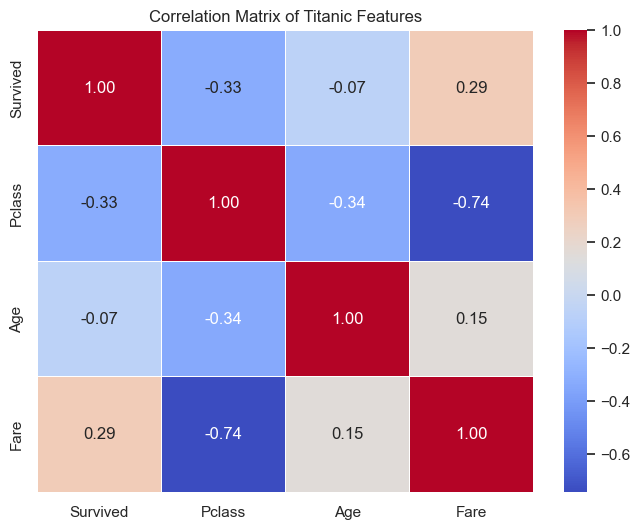

In [13]:
# Correlation Matrix
plt.figure(figsize=(8, 6))

# Prepare data for correlation (converting categories back to numeric temporarily)
heatmap_data = df.copy()
heatmap_data['Survived'] = heatmap_data['Survived'].astype(int)
heatmap_data['Pclass'] = heatmap_data['Pclass'].astype(int)
numeric_cols = heatmap_data.select_dtypes(include=[np.number])

sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Titanic Features')
plt.show()

In [18]:
# Survival Rate by Class and Gender
pivot_insight = pd.pivot_table(df, values='Survived', index='Pclass', columns='Sex', aggfunc=lambda x: x.astype(int).mean() * 100)
print("Survival Rate (%) by Class and Gender:")
display(pivot_insight.round(2))

Survival Rate (%) by Class and Gender:


Sex,female,male
Pclass,,
1,96.51,37.72
2,91.67,18.68
3,47.24,16.18


## Step 5: Conclusion
**Key Takeaways:**
1. **Gender Impact:** The "Women and children first" protocol was clearly executed. Females had a significantly higher survival rate compared to males.
2. **Socio-economic Status:** Passenger class heavily influenced survival. First-class passengers had priority access to lifeboats, resulting in the highest survival rate, while Third-class passengers suffered the most casualties.
3. **Correlation:** There is a strong relationship between the fare paid, the passenger class, and the likelihood of survival.

